In [291]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.ensemble import IsolationForest

In [292]:
# ===============================
# 2. LOAD DATA
# ===============================
train_file = "../data/raw/train_FD001.txt"
test_file = "../data/raw/test_FD001.txt"
rul_file = "../data/raw/RUL_FD001.txt"
# Load train
df_train = pd.read_csv(train_file, sep=r"\s+", header=None).iloc[:, :26]
# Load test
df_test = pd.read_csv(test_file, sep=r"\s+", header=None).iloc[:, :26]
# Load true RUL
y_true = pd.read_csv(rul_file, header=None)[0]
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)


In [293]:
# ===============================
# 3. ADD COLUMN NAMES
# ===============================
columns = ['engine_id', 'cycle'] + \
[f'op_setting_{i}' for i in range(1, 4)] + \
[f'sensor_{i}' for i in range(1, 22)]
df_train.columns = columns
df_test.columns = columns
df_train.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Number of engines: 100


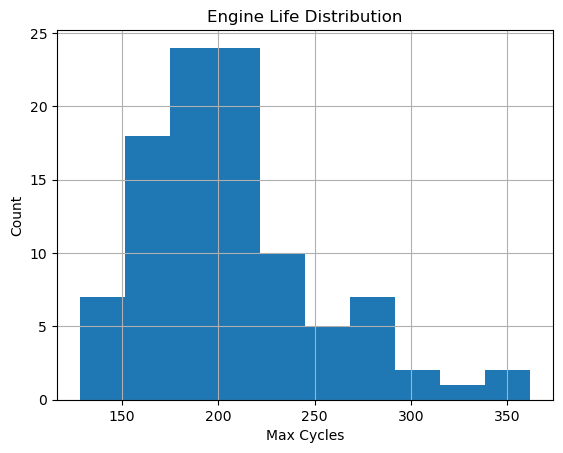

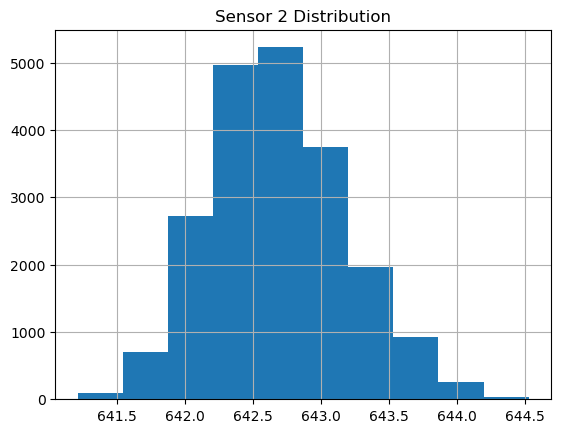

In [294]:
# ===============================
# 4. DATA DISTRIBUTION
# ===============================
# Number of engines
print("Number of engines:", df_train['engine_id'].nunique())
# Cycles distribution
df_train.groupby('engine_id')['cycle'].max().hist()
plt.title("Engine Life Distribution")
plt.xlabel("Max Cycles")
plt.ylabel("Count")
plt.show()
# Sensor distribution
df_train['sensor_2'].hist()
plt.title("Sensor 2 Distribution")
plt.show()

In [295]:
# ===============================
# 5. CREATE RUL
# ===============================
max_cycle = df_train.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id', 'max_cycle']
df_train = df_train.merge(max_cycle, on='engine_id')
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
df_train['RUL'] = df_train['RUL'].clip(upper=125)
df_train[['engine_id', 'cycle', 'RUL']].head()


,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


In [296]:
# ===============================
# 6. PREPROCESSING
# ===============================
important_sensors = [
    'sensor_2','sensor_3','sensor_4','sensor_7',
    'sensor_11','sensor_12','sensor_15',
    'sensor_17','sensor_20','sensor_21'
]
# Drop op settings
df_train = df_train.drop(columns=[c for c in df_train.columns if 'op_setting' in c])
df_test = df_test.drop(columns=[c for c in df_test.columns if 'op_setting' in c])
# Scaling
scaler = MinMaxScaler()
df_train[important_sensors] = scaler.fit_transform(df_train[important_sensors])
df_test[important_sensors] = scaler.transform(df_test[important_sensors])

In [297]:
# ===============================
# 7. FEATURE ENGINEERING (FIXED)
# ===============================
for col in important_sensors:
    df_train[f'{col}_ma'] = df_train.groupby('engine_id')[col].transform(lambda x: x.rolling(5).mean())
    df_train[f'{col}_std'] = df_train.groupby('engine_id')[col].transform(lambda x: x.rolling(5).std())
    df_train[f'{col}_trend'] = df_train.groupby('engine_id')[col].transform(lambda x: x.diff())
# Time feature (OUTSIDE LOOP)
df_train['cycle_norm'] = df_train['cycle'] / df_train.groupby('engine_id')['cycle'].transform('max')
# Lag features
for col in important_sensors:
    df_train[f'{col}_lag1'] = df_train.groupby('engine_id')[col].shift(1)
    df_train[f'{col}_lag2'] = df_train.groupby('engine_id')[col].shift(2)
# Fill missing values
df_train = df_train.bfill()

In [298]:
# ===============================
# 7.1 CLEAN FEATURE SET 
# ===============================
feature_cols = [
    col for col in df_train.columns
    if ('sensor_' in col) and ('slope' not in col)
]
print("Total features used:", len(feature_cols))

Total features used: 71


In [299]:
# ===============================
# 8. TRAIN MODEL
# ===============================

engine_ids = df_train['engine_id'].unique()

train_ids = engine_ids[:80]
val_ids = engine_ids[80:]

train_data = df_train[df_train['engine_id'].isin(train_ids)]
val_data = df_train[df_train['engine_id'].isin(val_ids)]

X_train = train_data[feature_cols]
y_train = train_data['RUL']

# FIRST define model
model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    random_state=42
)

# THEN train
model.fit(X_train, y_train)

print("Model trained successfully")

importance = model.feature_importances_

Model trained successfully


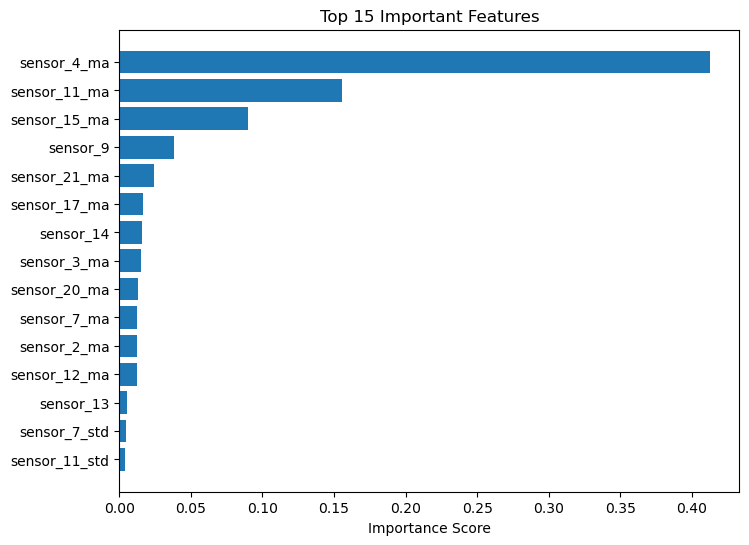

In [300]:
import matplotlib.pyplot as plt
import numpy as np

# Safety check
assert len(importance) == len(feature_cols), "Mismatch in features!"

# Sort indices
indices = np.argsort(importance)[-15:]

# Plot
plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.title("Top 15 Important Features")
plt.xlabel("Importance Score")
plt.show()

In [301]:
# ===============================
# 9. TEST MODEL 
# ===============================
for col in important_sensors:
    df_test[f'{col}_ma'] = df_test.groupby('engine_id')[col].transform(lambda x: x.rolling(5).mean())
    df_test[f'{col}_std'] = df_test.groupby('engine_id')[col].transform(lambda x: x.rolling(5).std())
    df_test[f'{col}_trend'] = df_test.groupby('engine_id')[col].transform(lambda x: x.diff())
# Time feature
df_test['cycle_norm'] = df_test['cycle'] / df_test.groupby('engine_id')['cycle'].transform('max')
# Lag features (IMPORTANT: BEFORE prediction)
for col in important_sensors:
    df_test[f'{col}_lag1'] = df_test.groupby('engine_id')[col].shift(1)
    df_test[f'{col}_lag2'] = df_test.groupby('engine_id')[col].shift(2)
# Fill missing values
df_test = df_test.bfill()
# Now create X_test (AFTER all features exist)
X_test = df_test[feature_cols]
# Predict
df_test['RUL_pred'] = model.predict(X_test)

In [302]:
# ===============================
# 10. EVALUATION
# ===============================
final_cycles = df_test.groupby('engine_id').last().reset_index()
y_pred = final_cycles['RUL_pred']
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 18.470380836943203
MAE: 13.461054801940918


In [303]:
from sklearn.metrics import r2_score

r2 = r2_score(y_true, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8024431467056274


In [304]:
# ===============================
# 11. ANOMALY DETECTION
# ===============================

# 1. Train Isolation Forest on healthy data
normal_data = df_train[df_train['RUL'] > 80][important_sensors]

iso_model = IsolationForest(
    contamination=0.06,
    n_estimators=300,
    random_state=42
)

iso_model.fit(normal_data)

# 2. Get anomaly score (NOT just labels)
df_train['iforest_score'] = iso_model.decision_function(df_train[important_sensors])

# Normalize score (0 to 1)
scaler_score = MinMaxScaler()
df_train['iforest_score'] = scaler_score.fit_transform(df_train[['iforest_score']])

# 3. Statistical anomaly score
df_train['sensor_score'] = df_train[important_sensors].std(axis=1)

# Normalize sensor score
df_train['sensor_score'] = scaler_score.fit_transform(df_train[['sensor_score']])

# 4. Combine both (HYBRID SCORE)
df_train['anomaly_score'] = (
    0.6 * (1 - df_train['iforest_score']) +
    0.2 * df_train['sensor_score'] +
    0.2 * (1 / (df_train['RUL'] + 1))
)
# 5. Final anomaly decision
threshold = df_train['anomaly_score'].quantile(0.75)
df_train['anomaly'] = (df_train['anomaly_score'] > threshold).astype(int)

df_train['risk_score'] = (
    0.5 * df_train['anomaly_score'] +
    0.3 * (1 / (df_train['RUL'] + 1)) +
    0.2 * df_train['sensor_score']
)

print("Advanced anomaly detection completed")

Advanced anomaly detection completed


In [305]:
# ===============================
# 12. CREATE TRUE LABELS
# ===============================

# Define anomaly if RUL < 30
df_train['true_anomaly'] = (df_train['RUL'] < 50).astype(int)

df_train[['RUL', 'true_anomaly']].head()
print(df_train[['anomaly', 'true_anomaly']].head())

   anomaly  true_anomaly
0        0             0
1        0             0
2        0             0
3        0             0
4        0             0


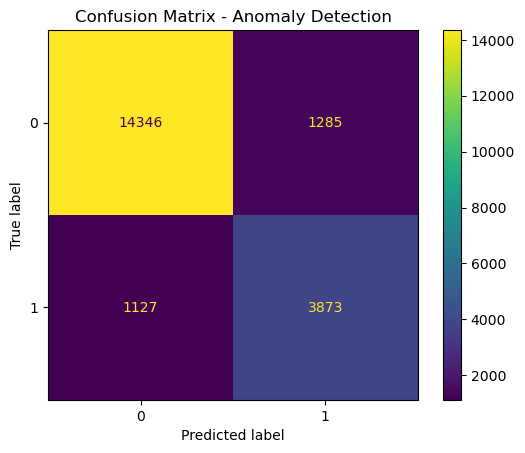

In [306]:
# ===============================
# 13. CONFUSION MATRIX
# ===============================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true_anom = df_train['true_anomaly']
y_pred_anom = df_train['anomaly']

cm = confusion_matrix(y_true_anom, y_pred_anom)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Anomaly Detection")
plt.show()

In [307]:
# ===============================
# 14. ANOMALY METRICS
# ===============================

from sklearn.metrics import classification_report

print(classification_report(y_true_anom, y_pred_anom))



              precision    recall  f1-score   support

           0       0.93      0.92      0.92     15631
           1       0.75      0.77      0.76      5000

    accuracy                           0.88     20631
   macro avg       0.84      0.85      0.84     20631
weighted avg       0.88      0.88      0.88     20631



In [308]:
# ===============================
# 12. DECISION ENGINE 
# ===============================
def decision(row):
    if row['risk_score'] > 0.8:
        return "CRITICAL: Shutdown subsystem"
    elif row['risk_score'] > 0.6:
        return "HIGH RISK: Switch to backup"
    elif row['risk_score'] > 0.4:
        return "WARNING: Monitor closely"
    else:
        return "NORMAL"

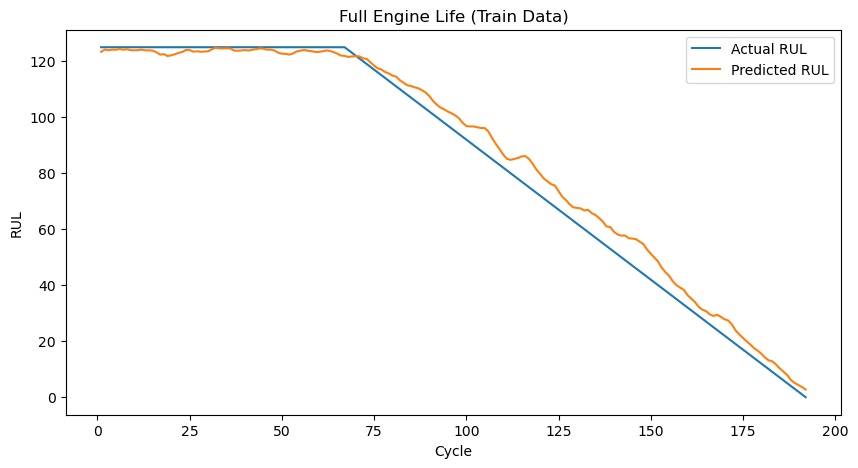

In [309]:
# ===============================
# 13. VISUALIZATION
# ===============================

engine_id = 1
engine = df_train[df_train['engine_id'] == engine_id]
plt.figure(figsize=(10,5))

# plt.plot(engine['cycle'], engine['RUL'], label='Actual RUL')
# plt.plot(engine['cycle'], model.predict(engine[feature_cols]), label='Predicted RUL')
pred = model.predict(engine[feature_cols])

# Smooth using rolling average
pred_smooth = pd.Series(pred).rolling(5, min_periods=1).mean()

plt.plot(engine['cycle'], engine['RUL'], label='Actual RUL')
plt.plot(engine['cycle'], pred_smooth, label='Predicted RUL')
plt.legend()
plt.title("Full Engine Life (Train Data)")
plt.xlabel("Cycle")
plt.ylabel("RUL")

plt.show()

Final Model Evaluation:
RMSE: 18.47
MAE: 13.46


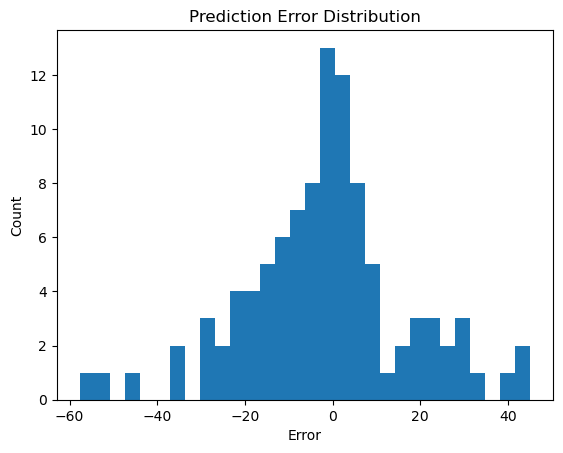

In [310]:
# ===============================
# FINAL MODEL PERFORMANCE
# ===============================

print("Final Model Evaluation:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Error distribution
errors = y_true - y_pred

plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()